# Final demand-model selection

This notebook finalizes the predictive demand specification before local-support and reliability calibration.

It implements two changes motivated by the previous diagnostics:

1. **Reproducible product selection.** Products must have adequate availability, observed-price variation, and promotion variation. Eligible products are ranked only by training-period unit sales.
2. **Promotion refinements.** The stable common price spline is compared with:
   - product-specific promotion and post-promotion effects;
   - product-specific promotion effects plus observed discount depth.

Store–product fixed effects are retained in every PPML specification. Model selection uses the calibration period only; the test period remains untouched until the preferred specification has been frozen.

The models remain predictive rather than causal.

## 1. Imports and configuration

In [12]:
from pathlib import Path
from time import perf_counter
import gc
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore", category=FutureWarning)

# Locate the repository whether the notebook starts from the repository root
# or from the notebooks directory.
CURRENT_DIR = Path.cwd().resolve()
POSSIBLE_ROOTS = [CURRENT_DIR, CURRENT_DIR.parent]

PROJECT_ROOT = next(
    (
        root
        for root in POSSIBLE_ROOTS
        if (root / "data" / "processed").is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not locate the project root from {CURRENT_DIR}"
    )

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cereal_demand_model_data.parquet"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Sample size.
N_PRODUCTS = 8
N_STORES = 15

# Chronological split.
TRAIN_SHARE = 0.60
CALIBRATION_SHARE = 0.20

# Product eligibility.
MIN_PRODUCT_TRAIN_WEEKS = 100
MIN_PRODUCT_CALIBRATION_WEEKS = 40
MIN_PRODUCT_TEST_WEEKS = 40
MIN_PRODUCT_TRAIN_STORES = 10
MIN_PRODUCT_DISTINCT_PRICES = 8
MIN_PRODUCT_PROMOTION_ROWS = 30
MIN_PRODUCT_REGULAR_ROWS = 100
MAX_PRODUCT_IMPUTED_SHARE = 0.25
MIN_PRODUCT_RELATIVE_PRICE_RANGE = 0.10

# Store and panel eligibility.
MIN_STORE_TRAIN_WEEKS = 100
MIN_STORE_CALIBRATION_WEEKS = 40
MIN_STORE_TEST_WEEKS = 40
MIN_PRODUCT_COVERAGE_SHARE = 0.75

MIN_PANEL_TRAIN_WEEKS = 100
MIN_PANEL_CALIBRATION_WEEKS = 30
MIN_PANEL_TEST_WEEKS = 30

# Refit every four observed week values in the main specification.
# Increase to 8 or 12 only while debugging.
REFIT_EVERY_N_WEEKS = 4

# Set to True only if discount_depth is stored in percentage points,
# e.g. 20 for a 20% discount rather than 0.20.
DISCOUNT_DEPTH_IS_PERCENT = False

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Data file exists:", DATA_PATH.is_file())

Project root: C:\Users\janza\price-of-extrapolation
Data path: C:\Users\janza\price-of-extrapolation\data\processed\cereal_demand_model_data.parquet
Data file exists: True


## 2. Load and validate the cleaned data

In [13]:
required_columns = [
    "store",
    "upc",
    "store_upc",
    "week",
    "week_start",
    "week_end",
    "move",
    "model_unit_price",
    "unit_price_observed",
    "log_price",
    "regular_price",
    "discount_depth",
    "price_source",
    "price_imputed",
    "tier_week_price_donors",
    "price_tier",
    "sale",
    "promo_recorded",
    "promo_from_discount",
    "promo_state",
    "post_promo",
    "pricing_state",
    "calendar_month",
    "scaled_time_trend",
    "thanksgiving_week",
    "christmas_week",
    "new_year_week",
    "easter_week",
    "gross_margin_pct_observed",
]

raw = pd.read_parquet(
    DATA_PATH,
    columns=required_columns,
)

missing_columns = set(required_columns).difference(
    raw.columns
)

if missing_columns:
    raise ValueError(
        f"Missing source columns: {sorted(missing_columns)}"
    )

data = raw.copy()
del raw

In [14]:
data["store"] = data["store"].astype(str)
data["upc"] = data["upc"].astype(str)
data["store_upc"] = data["store_upc"].astype(str)

data["week"] = pd.to_numeric(
    data["week"],
    errors="coerce",
)

data["move"] = pd.to_numeric(
    data["move"],
    errors="coerce",
)

data["model_unit_price"] = pd.to_numeric(
    data["model_unit_price"],
    errors="coerce",
)

data["price_imputed"] = (
    data["price_imputed"]
    .fillna(False)
    .astype(bool)
)

data["price_imputed_indicator"] = (
    data["price_imputed"]
    .astype(int)
)

In [15]:
pricing_state_normalized = (
    data["pricing_state"]
    .astype("string")
    .fillna("unknown")
    .str.strip()
    .str.lower()
    .str.replace("-", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

data["promotion_indicator"] = (
    pricing_state_normalized
    .isin(["promotion", "promo"])
    .astype(int)
)

data["post_promotion_indicator"] = (
    pricing_state_normalized
    .isin(
        [
            "post_promotion",
            "postpromo",
            "post_promo",
        ]
    )
    .astype(int)
)

## 3. Define the chronological split before selecting products

Training-period outcomes determine the ranking. Calibration- and test-period data are used only to verify that a product remains available for evaluation.

In [16]:
all_weeks = np.sort(data["week"].unique())
n_all_weeks = len(all_weeks)

train_end_index = int(np.floor(TRAIN_SHARE * n_all_weeks))
calibration_end_index = int(
    np.floor(
        (TRAIN_SHARE + CALIBRATION_SHARE)
        * n_all_weeks
    )
)

train_weeks = all_weeks[:train_end_index]
calibration_weeks = all_weeks[
    train_end_index:calibration_end_index
]
test_weeks = all_weeks[calibration_end_index:]

print(
    f"Training: {train_weeks[0]}–{train_weeks[-1]} "
    f"({len(train_weeks)} weeks)"
)
print(
    f"Calibration: {calibration_weeks[0]}–{calibration_weeks[-1]} "
    f"({len(calibration_weeks)} weeks)"
)
print(
    f"Test: {test_weeks[0]}–{test_weeks[-1]} "
    f"({len(test_weeks)} weeks)"
)

Training: 5–218 (214 weeks)
Calibration: 220–325 (72 weeks)
Test: 326–399 (72 weeks)


## 4. Construct the product-eligibility table

In [33]:
allowed_pricing_states = {
    "regular",
    "promotion",
    "post_promotion",
}

if data["pricing_state"].isna().any():
    raise ValueError("pricing_state contains missing values.")

observed_pricing_states = set(
    data["pricing_state"].astype(str).unique()
)

unexpected_states = (
    observed_pricing_states - allowed_pricing_states
)

if unexpected_states:
    raise ValueError(
        f"Unexpected pricing states: {sorted(unexpected_states)}"
    )

# Keep indicators numerical so Patsy treats them as 0/1 regressors.
data["promotion_indicator"] = (
    data["pricing_state"]
    .eq("promotion")
    .astype("int8")
)

data["post_promotion_indicator"] = (
    data["pricing_state"]
    .eq("post_promotion")
    .astype("int8")
)

data["regular_indicator"] = (
    data["pricing_state"]
    .eq("regular")
    .astype("int8")
)

assert not (
    data["promotion_indicator"].eq(1)
    & data["regular_indicator"].eq(1)
).any()

In [34]:
def period_availability(
    frame: pd.DataFrame,
    group_column: str,
    prefix: str,
) -> pd.DataFrame:
    """Calculate panel availability without using future sales totals."""

    return (
        frame.groupby(
            group_column,
            observed=True,
        )
        .agg(
            **{
                f"{prefix}_rows": ("move", "size"),
                f"{prefix}_weeks": ("week", "nunique"),
                f"{prefix}_stores": ("store", "nunique"),
            }
        )
    )

In [35]:
def build_product_selection_table(
    frame: pd.DataFrame,
    train_week_values: np.ndarray,
    calibration_week_values: np.ndarray,
    test_week_values: np.ndarray,
) -> tuple[pd.DataFrame, list[str]]:
    required_columns = {
        "upc",
        "store",
        "week",
        "move",
        "model_unit_price",
        "price_imputed",
        "promotion_indicator",
        "regular_indicator",
    }

    missing_columns = required_columns.difference(
        frame.columns
    )

    if missing_columns:
        raise ValueError(
            "Product-selection data are missing columns: "
            f"{sorted(missing_columns)}"
        )

    train_data = frame[
        frame["week"].isin(train_week_values)
    ]
    calibration_data = frame[
        frame["week"].isin(calibration_week_values)
    ]
    test_data = frame[
        frame["week"].isin(test_week_values)
    ]

    observed_train = train_data.loc[
        ~train_data["price_imputed"]
    ]

    train_detail = (
        train_data.groupby("upc", observed=True)
        .agg(
            train_units=("move", "sum"),
            train_rows=("move", "size"),
            train_weeks=("week", "nunique"),
            train_stores=("store", "nunique"),
            train_promotion_rows=(
                "promotion_indicator",
                "sum",
            ),
            train_regular_rows=(
                "regular_indicator",
                "sum",
            ),
            train_imputed_share=(
                "price_imputed",
                "mean",
            ),
        )
    )

    observed_price_detail = (
        observed_train.groupby("upc", observed=True)
        .agg(
            train_distinct_prices=(
                "model_unit_price",
                "nunique",
            ),
            train_log_price_sd=(
                "model_unit_price",
                lambda x: np.log(x).std(),
            ),
            train_price_p10=(
                "model_unit_price",
                lambda x: x.quantile(0.10),
            ),
            train_price_p90=(
                "model_unit_price",
                lambda x: x.quantile(0.90),
            ),
        )
    )

    calibration_availability = period_availability(
        calibration_data,
        "upc",
        "calibration",
    )

    test_availability = period_availability(
        test_data,
        "upc",
        "test",
    )

    selection = (
        train_detail
        .join(observed_price_detail, how="left")
        .join(calibration_availability, how="left")
        .join(test_availability, how="left")
        .fillna(0)
        .reset_index()
    )

    selection["train_relative_price_range"] = (
        selection["train_price_p90"]
        / selection["train_price_p10"].replace(0, np.nan)
        - 1.0
    )

    criteria = {
        "adequate_train_weeks": (
            selection["train_weeks"]
            >= MIN_PRODUCT_TRAIN_WEEKS
        ),
        "adequate_calibration_weeks": (
            selection["calibration_weeks"]
            >= MIN_PRODUCT_CALIBRATION_WEEKS
        ),
        "adequate_test_weeks": (
            selection["test_weeks"]
            >= MIN_PRODUCT_TEST_WEEKS
        ),
        "adequate_store_coverage": (
            selection["train_stores"]
            >= MIN_PRODUCT_TRAIN_STORES
        ),
        "adequate_distinct_prices": (
            selection["train_distinct_prices"]
            >= MIN_PRODUCT_DISTINCT_PRICES
        ),
        "adequate_promotions": (
            selection["train_promotion_rows"]
            >= MIN_PRODUCT_PROMOTION_ROWS
        ),
        "adequate_regular_rows": (
            selection["train_regular_rows"]
            >= MIN_PRODUCT_REGULAR_ROWS
        ),
        "acceptable_imputation": (
            selection["train_imputed_share"]
            <= MAX_PRODUCT_IMPUTED_SHARE
        ),
        "adequate_price_range": (
            selection["train_relative_price_range"]
            >= MIN_PRODUCT_RELATIVE_PRICE_RANGE
        ),
    }

    for name, criterion in criteria.items():
        selection[name] = criterion

    criterion_columns = list(criteria)

    selection["eligible"] = (
        selection[criterion_columns]
        .all(axis=1)
    )

    selection = (
        selection
        .sort_values(
            ["eligible", "train_units"],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )

    return selection, criterion_columns

In [36]:
product_selection, product_criteria = (
    build_product_selection_table(
        frame=data,
        train_week_values=train_weeks,
        calibration_week_values=calibration_weeks,
        test_week_values=test_weeks,
    )
)

display(product_selection.head(25))

,upc,train_units,train_rows,train_weeks,train_stores,train_promotion_rows,train_regular_rows,train_imputed_share,train_distinct_prices,train_log_price_sd,...,adequate_train_weeks,adequate_calibration_weeks,adequate_test_weeks,adequate_store_coverage,adequate_distinct_prices,adequate_promotions,adequate_regular_rows,acceptable_imputation,adequate_price_range,eligible
0,1600066610,1145958,17431,214,86,2749,13236,0.010728,169,0.094572,...,True,True,True,True,True,True,True,True,True,True
1,1600066510,1047983,17423,214,86,1884,14885,0.014291,140,0.096468,...,True,True,True,True,True,True,True,True,True,True
2,3800000120,1019806,17431,214,86,2837,13185,0.007802,103,0.108400,...,True,True,True,True,True,True,True,True,True,True
3,1600066590,833856,17431,214,86,2303,13892,0.012621,170,0.108084,...,True,True,True,True,True,True,True,True,True,True
4,3800000110,741516,17431,214,86,714,16378,0.017899,67,0.079581,...,True,True,True,True,True,True,True,True,True,True
5,3800001520,721180,17431,214,86,2045,14041,0.008950,95,0.084300,...,True,True,True,True,True,True,True,True,True,True
6,3800000127,703863,17431,214,86,2105,14379,0.008777,143,0.101559,...,True,True,True,True,True,True,True,True,True,True
7,3800001611,655460,17431,214,86,1720,14885,0.008777,89,0.085936,...,True,True,True,True,True,True,True,True,True,True
8,1600065850,638515,17431,214,86,2347,13805,0.011990,154,0.098540,...,True,True,True,True,True,True,True,True,True,True
9,3800001510,626879,17431,214,86,974,16042,0.011302,99,0.067775,...,True,True,True,True,True,True,True,True,True,True


## 5. Product-selection flow and final products

In [37]:
flow_rows = []
active = pd.Series(
    True,
    index=product_selection.index,
)

flow_rows.append(
    {
        "stage": "Products in cleaned sample",
        "products_remaining": int(active.sum()),
    }
)

for criterion in product_criteria:
    active &= product_selection[criterion]
    flow_rows.append(
        {
            "stage": criterion,
            "products_remaining": int(active.sum()),
        }
    )

product_selection_flow = pd.DataFrame(flow_rows)
display(product_selection_flow)

eligible_product_count = int(
    product_selection["eligible"].sum()
)

if eligible_product_count < N_PRODUCTS:
    warnings.warn(
        f"Only {eligible_product_count} products satisfy all criteria; "
        f"fewer than the requested {N_PRODUCTS} will be used."
    )

selected_upcs = (
    product_selection.loc[
        product_selection["eligible"],
        "upc",
    ]
    .head(N_PRODUCTS)
    .astype(str)
    .tolist()
)

if not selected_upcs:
    raise RuntimeError(
        "No products satisfy the eligibility criteria. "
        "Inspect product_selection before changing thresholds."
    )

print("Selected UPCs:")
for upc in selected_upcs:
    print(upc)

display(
    product_selection[
        product_selection["upc"].isin(selected_upcs)
    ]
)

,stage,products_remaining
0,Products in cleaned sample,344
1,adequate_train_weeks,175
2,adequate_calibration_weeks,133
3,adequate_test_weeks,106
4,adequate_store_coverage,105
5,adequate_distinct_prices,105
6,adequate_promotions,105
7,adequate_regular_rows,105
8,acceptable_imputation,97
9,adequate_price_range,97


Selected UPCs:
1600066610
1600066510
3800000120
1600066590
3800000110
3800001520
3800000127
3800001611


,upc,train_units,train_rows,train_weeks,train_stores,train_promotion_rows,train_regular_rows,train_imputed_share,train_distinct_prices,train_log_price_sd,...,adequate_train_weeks,adequate_calibration_weeks,adequate_test_weeks,adequate_store_coverage,adequate_distinct_prices,adequate_promotions,adequate_regular_rows,acceptable_imputation,adequate_price_range,eligible
0,1600066610,1145958,17431,214,86,2749,13236,0.010728,169,0.094572,...,True,True,True,True,True,True,True,True,True,True
1,1600066510,1047983,17423,214,86,1884,14885,0.014291,140,0.096468,...,True,True,True,True,True,True,True,True,True,True
2,3800000120,1019806,17431,214,86,2837,13185,0.007802,103,0.108400,...,True,True,True,True,True,True,True,True,True,True
3,1600066590,833856,17431,214,86,2303,13892,0.012621,170,0.108084,...,True,True,True,True,True,True,True,True,True,True
4,3800000110,741516,17431,214,86,714,16378,0.017899,67,0.079581,...,True,True,True,True,True,True,True,True,True,True
5,3800001520,721180,17431,214,86,2045,14041,0.008950,95,0.084300,...,True,True,True,True,True,True,True,True,True,True
6,3800000127,703863,17431,214,86,2105,14379,0.008777,143,0.101559,...,True,True,True,True,True,True,True,True,True,True
7,3800001611,655460,17431,214,86,1720,14885,0.008777,89,0.085936,...,True,True,True,True,True,True,True,True,True,True


## 6. Select stores using training sales and availability

Stores are ranked by training-period unit sales after the products are frozen. Calibration and test periods are used only to require continued availability and product coverage.

In [38]:
selected_product_data = data[
    data["upc"].isin(selected_upcs)
].copy()

train_store_data = selected_product_data[
    selected_product_data["week"].isin(train_weeks)
]
calibration_store_data = selected_product_data[
    selected_product_data["week"].isin(calibration_weeks)
]
test_store_data = selected_product_data[
    selected_product_data["week"].isin(test_weeks)
]

store_training = (
    train_store_data.groupby("store", observed=True)
    .agg(
        train_units=("move", "sum"),
        train_weeks=("week", "nunique"),
        train_products=("upc", "nunique"),
    )
)

store_calibration = (
    calibration_store_data.groupby("store", observed=True)
    .agg(
        calibration_weeks=("week", "nunique"),
        calibration_products=("upc", "nunique"),
    )
)

store_test = (
    test_store_data.groupby("store", observed=True)
    .agg(
        test_weeks=("week", "nunique"),
        test_products=("upc", "nunique"),
    )
)

store_selection = (
    store_training
    .join(store_calibration, how="left")
    .join(store_test, how="left")
    .fillna(0)
    .reset_index()
)

minimum_product_coverage = max(
    1,
    int(
        np.ceil(
            MIN_PRODUCT_COVERAGE_SHARE
            * len(selected_upcs)
        )
    ),
)

store_selection["eligible"] = (
    (store_selection["train_weeks"] >= MIN_STORE_TRAIN_WEEKS)
    & (
        store_selection["calibration_weeks"]
        >= MIN_STORE_CALIBRATION_WEEKS
    )
    & (store_selection["test_weeks"] >= MIN_STORE_TEST_WEEKS)
    & (
        store_selection["train_products"]
        >= minimum_product_coverage
    )
    & (
        store_selection["calibration_products"]
        >= minimum_product_coverage
    )
    & (
        store_selection["test_products"]
        >= minimum_product_coverage
    )
)

store_selection = store_selection.sort_values(
    ["eligible", "train_units"],
    ascending=[False, False],
).reset_index(drop=True)

selected_stores = (
    store_selection.loc[
        store_selection["eligible"],
        "store",
    ]
    .head(N_STORES)
    .astype(str)
    .tolist()
)

if not selected_stores:
    raise RuntimeError(
        "No stores satisfy the availability and product-coverage criteria."
    )

print("Selected stores:")
print(selected_stores)
display(store_selection.head(25))

Selected stores:
['102', '73', '8', '80', '124', '18', '128', '74', '111', '109', '122', '70', '132', '98', '114']


,store,train_units,train_weeks,train_products,calibration_weeks,calibration_products,test_weeks,test_products,eligible
0,102,151213,205,8,72,8,72.0,8.0,True
1,73,146147,211,8,72,8,72.0,8.0,True
2,8,129225,210,8,72,8,72.0,8.0,True
3,80,126035,212,8,72,8,72.0,8.0,True
4,124,123995,200,8,72,8,72.0,8.0,True
5,18,123884,206,8,72,8,72.0,8.0,True
6,128,119047,207,8,72,8,72.0,8.0,True
7,74,114509,210,8,72,8,72.0,8.0,True
8,111,111299,213,8,72,8,72.0,8.0,True
9,109,110500,208,8,72,8,72.0,8.0,True


## 7. Retain store–product panels with adequate observations in every period

In [39]:
candidate_sample = selected_product_data[
    selected_product_data["store"].isin(selected_stores)
].copy()

def panel_period_counts(
    frame: pd.DataFrame,
    week_values: np.ndarray,
    prefix: str,
) -> pd.DataFrame:
    return (
        frame[frame["week"].isin(week_values)]
        .groupby("store_upc", observed=True)
        .agg(
            **{
                f"{prefix}_weeks": ("week", "nunique"),
                f"{prefix}_rows": ("move", "size"),
            }
        )
    )

panel_selection = (
    panel_period_counts(
        candidate_sample,
        train_weeks,
        "train",
    )
    .join(
        panel_period_counts(
            candidate_sample,
            calibration_weeks,
            "calibration",
        ),
        how="left",
    )
    .join(
        panel_period_counts(
            candidate_sample,
            test_weeks,
            "test",
        ),
        how="left",
    )
    .fillna(0)
    .reset_index()
)

panel_selection["eligible"] = (
    (panel_selection["train_weeks"] >= MIN_PANEL_TRAIN_WEEKS)
    & (
        panel_selection["calibration_weeks"]
        >= MIN_PANEL_CALIBRATION_WEEKS
    )
    & (panel_selection["test_weeks"] >= MIN_PANEL_TEST_WEEKS)
)

eligible_panels = panel_selection.loc[
    panel_selection["eligible"],
    "store_upc",
].astype(str)

sample = candidate_sample[
    candidate_sample["store_upc"].isin(eligible_panels)
].copy()

sample = sample.sort_values(
    ["store_upc", "week"]
).reset_index(drop=True)

print(f"Rows: {len(sample):,}")
print(f"Products retained: {sample['upc'].nunique()}")
print(f"Stores retained: {sample['store'].nunique()}")
print(f"Panels retained: {sample['store_upc'].nunique()}")
print(f"Weeks retained: {sample['week'].nunique()}")

product_panel_coverage = (
    sample.groupby("upc", observed=True)
    .agg(
        panels=("store_upc", "nunique"),
        stores=("store", "nunique"),
        train_rows=(
            "week",
            lambda x: np.isin(x, train_weeks).sum(),
        ),
        calibration_rows=(
            "week",
            lambda x: np.isin(x, calibration_weeks).sum(),
        ),
        test_rows=(
            "week",
            lambda x: np.isin(x, test_weeks).sum(),
        ),
    )
    .reset_index()
)

display(product_panel_coverage)

Rows: 42,285
Products retained: 8
Stores retained: 15
Panels retained: 120
Weeks retained: 358


,upc,panels,stores,train_rows,calibration_rows,test_rows
0,1600066510,15,15,3124,1080,1080
1,1600066590,15,15,3126,1080,1080
2,1600066610,15,15,3126,1080,1080
3,3800000110,15,15,3126,1080,1080
4,3800000120,15,15,3126,1080,1080
5,3800000127,15,15,3126,1080,1080
6,3800001520,15,15,3126,1079,1080
7,3800001611,15,15,3126,1080,1080


## 8. Construct strictly past-looking demand features

In [40]:
sample = (
    sample
    .sort_values(
        ["store_upc", "week"],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

duplicate_count = sample.duplicated(
    ["store_upc", "week"]
).sum()

if duplicate_count:
    raise ValueError(
        f"Found {duplicate_count} duplicate panel-week rows."
    )

grouped = sample.groupby(
    "store_upc",
    observed=True,
    sort=False,
)

sample["week_gap"] = grouped["week"].diff()

previous_move = grouped["move"].shift(1)
previous_price = grouped["model_unit_price"].shift(1)

consecutive_previous_week = sample["week_gap"].eq(1)

sample["lag_move_1"] = previous_move.where(
    consecutive_previous_week
)
sample["lag_price_1"] = previous_price.where(
    consecutive_previous_week
)

del previous_move, previous_price

In [41]:
lagged_moves = []

for lag in range(1, 5):
    previous_week = grouped["week"].shift(lag)
    previous_move = grouped["move"].shift(lag)

    exact_calendar_lag = (
        sample["week"] - previous_week
    ).eq(lag)

    lagged_moves.append(
        previous_move
        .where(exact_calendar_lag)
        .rename(f"lag_move_{lag}")
    )

lagged_move_frame = pd.concat(
    lagged_moves,
    axis=1,
)

valid_lag_count = lagged_move_frame.notna().sum(axis=1)

sample["lag_move_mean_4"] = (
    lagged_move_frame
    .mean(axis=1)
    .where(valid_lag_count >= 2)
)

del (
    lagged_moves,
    lagged_move_frame,
    valid_lag_count,
    previous_week,
    previous_move,
    exact_calendar_lag,
)

In [42]:
sample["log1p_lag_move"] = np.log1p(
    sample["lag_move_1"]
)
sample["log1p_lag_move_mean_4"] = np.log1p(
    sample["lag_move_mean_4"]
)

sample["reference_price"] = sample["lag_price_1"]

sample["log_price_model"] = np.log(
    sample["model_unit_price"]
)

sample["price_imputed_indicator"] = (
    sample["price_imputed"].astype("int8")
)

binary_model_columns = [
    "promotion_indicator",
    "post_promotion_indicator",
    "thanksgiving_week",
    "christmas_week",
    "new_year_week",
    "easter_week",
    "price_imputed_indicator",
]

for column in binary_model_columns:
    sample[column] = (
        pd.to_numeric(
            sample[column],
            errors="raise",
        )
        .astype("int8")
    )

    unexpected_values = set(
        sample[column].dropna().unique()
    ) - {0, 1}

    if unexpected_values:
        raise ValueError(
            f"{column} contains nonbinary values: "
            f"{sorted(unexpected_values)}"
        )


sample["calendar_month"] = (
    sample["calendar_month"]
    .astype("string")
    .fillna("unknown")
)

discount_depth_model = pd.to_numeric(
    sample["discount_depth"],
    errors="coerce",
)

if DISCOUNT_DEPTH_IS_PERCENT:
    discount_depth_model = (
        discount_depth_model / 100.0
    )

invalid_discount = (
    discount_depth_model.notna()
    & ~discount_depth_model.between(
        0.0,
        1.0,
        inclusive="left",
    )
)

if invalid_discount.any():
    raise ValueError(
        "discount_depth must lie in [0, 1)."
    )

sample["discount_depth_model"] = (
    discount_depth_model.astype("float64")
)

sample["discount_depth_sq"] = (
    sample["discount_depth_model"] ** 2
)

del discount_depth_model, invalid_discount

model_columns = [
    "move",
    "log_price_model",
    "promotion_indicator",
    "post_promotion_indicator",
    "discount_depth_model",
    "discount_depth_sq",
    "calendar_month",
    "scaled_time_trend",
    "thanksgiving_week",
    "christmas_week",
    "new_year_week",
    "easter_week",
    "log1p_lag_move",
    "log1p_lag_move_mean_4",
    "lag_move_1",
    "lag_move_mean_4",
    "price_imputed_indicator",
    "store_upc",
    "upc",
    "week",
]

missing_model_columns = set(model_columns).difference(
    sample.columns
)

if missing_model_columns:
    raise ValueError(
        "Missing modelling columns: "
        f"{sorted(missing_model_columns)}"
    )

model_data = sample.dropna(
    subset=model_columns
).copy()


finite_model_columns = [
    "move",
    "log_price_model",
    "discount_depth_model",
    "discount_depth_sq",
    "scaled_time_trend",
    "log1p_lag_move",
    "log1p_lag_move_mean_4",
]

finite_matrix = model_data[
    finite_model_columns
].to_numpy(dtype="float64")

if not np.isfinite(finite_matrix).all():
    bad_counts = {
        column: int(
            ~np.isfinite(
                model_data[column].to_numpy(
                    dtype="float64"
                )
            )
        ).sum()
        for column in finite_model_columns
    }

    raise ValueError(
        f"Nonfinite modelling values: {bad_counts}"
    )

del finite_matrix


for column in [
    "store_upc",
    "upc",
    "calendar_month",
]:
    model_data[column] = (
        model_data[column].astype("category")
    )

observed_transition = sample["week_gap"].notna()
nonconsecutive = (
    observed_transition
    & sample["week_gap"].ne(1)
)

nonconsecutive_share = nonconsecutive.loc[
    observed_transition
].mean()

print(
    f"Rows available for modelling: "
    f"{len(model_data):,}"
)
print(
    "Nonconsecutive panel transitions: "
    f"{nonconsecutive_share:.3%}"
)

Rows available for modelling: 40,381
Nonconsecutive panel transitions: 2.011%


## 9. Recreate the three evaluation samples

In [43]:
train = model_data[
    model_data["week"].isin(train_weeks)
].copy()
calibration = model_data[
    model_data["week"].isin(calibration_weeks)
].copy()
test = model_data[
    model_data["week"].isin(test_weeks)
].copy()

split_summary = pd.DataFrame(
    {
        "split": ["train", "calibration", "test"],
        "rows": [len(train), len(calibration), len(test)],
        "weeks": [
            train["week"].nunique(),
            calibration["week"].nunique(),
            test["week"].nunique(),
        ],
        "products": [
            train["upc"].nunique(),
            calibration["upc"].nunique(),
            test["upc"].nunique(),
        ],
        "stores": [
            train["store"].nunique(),
            calibration["store"].nunique(),
            test["store"].nunique(),
        ],
        "panels": [
            train["store_upc"].nunique(),
            calibration["store_upc"].nunique(),
            test["store_upc"].nunique(),
        ],
    }
)

display(split_summary)

,split,rows,weeks,products,stores,panels
0,train,24063,212,8,15,120
1,calibration,7918,66,8,15,120
2,test,8400,70,8,15,120


## 10. Forecast-loss functions

In [44]:
def poisson_deviance_contribution(
    observed: pd.Series | np.ndarray,
    predicted: pd.Series | np.ndarray,
) -> np.ndarray:
    y = np.asarray(observed, dtype=float)
    mu = np.clip(
        np.asarray(predicted, dtype=float),
        1e-12,
        None,
    )

    log_term = np.zeros_like(y, dtype=float)
    positive = y > 0
    log_term[positive] = (
        y[positive]
        * np.log(y[positive] / mu[positive])
    )

    return 2.0 * (
        log_term - (y - mu)
    )


def prediction_metrics(
    frame: pd.DataFrame,
) -> pd.Series:
    y = frame["move"].to_numpy(dtype=float)
    mu = frame["mu_hat"].to_numpy(dtype=float)
    deviance = poisson_deviance_contribution(y, mu)

    return pd.Series(
        {
            "n": len(frame),
            "mean_observed": y.mean(),
            "mean_predicted": mu.mean(),
            "observed_to_predicted_ratio": (
                y.sum() / mu.sum()
            ),
            "mae": np.mean(np.abs(y - mu)),
            "rmse": np.sqrt(np.mean((y - mu) ** 2)),
            "mean_poisson_deviance": deviance.mean(),
            "median_poisson_deviance": np.median(deviance),
            "p90_poisson_deviance": np.quantile(
                deviance,
                0.90,
            ),
        }
    )

## 11. PPML specifications

All specifications retain store–product fixed effects and the same lag/calendar controls.

- `common_spline`: common nonlinear price curve and common promotion-state effects;
- `product_promotion`: common price curve and product-specific promotion/post-promotion effects;
- `product_promotion_depth`: additionally controls for observed discount depth and its square.

Discount depth must later be recomputed for every counterfactual candidate price.

In [45]:
COMMON_CONTROLS = (
    " + log1p_lag_move"
    " + log1p_lag_move_mean_4"
    " + C(calendar_month)"
    " + scaled_time_trend"
    " + thanksgiving_week"
    " + christmas_week"
    " + new_year_week"
    " + easter_week"
    " + price_imputed_indicator"
)


def spline_expression(
    lower_bound: float,
    upper_bound: float,
) -> str:
    return (
        "bs("
        "log_price_spline, "
        "df=4, "
        "degree=3, "
        "include_intercept=False, "
        f"lower_bound={repr(float(lower_bound))}, "
        f"upper_bound={repr(float(upper_bound))}"
        ")"
    )


def build_formula(
    model_name: str,
    lower_bound: float,
    upper_bound: float,
) -> str:
    fixed_effects = "0 + C(store_upc)"
    price_spline = spline_expression(
        lower_bound,
        upper_bound,
    )

    if model_name == "common_spline":
        promotion_terms = (
            " + promotion_indicator"
            " + post_promotion_indicator"
        )
    elif model_name == "product_promotion":
        promotion_terms = (
            " + C(upc):promotion_indicator"
            " + C(upc):post_promotion_indicator"
        )
    elif model_name == "product_promotion_depth":
        promotion_terms = (
            " + C(upc):promotion_indicator"
            " + C(upc):post_promotion_indicator"
            " + discount_depth_model"
            " + discount_depth_sq"
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")

    return (
        "move ~ "
        + fixed_effects
        + " + "
        + price_spline
        + promotion_terms
        + COMMON_CONTROLS
    )


PPML_MODELS = [
    "common_spline",
    "product_promotion",
    "product_promotion_depth",
]

## 12. Expanding-window PPML forecasts

In [46]:
def prepare_price_for_spline(
    fit_data: pd.DataFrame,
    prediction_data: pd.DataFrame,
    lower_quantile: float = 0.001,
    upper_quantile: float = 0.999,
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    float,
    float,
]:
    fit_copy = fit_data.copy()
    prediction_copy = prediction_data.copy()

    lower = float(
        fit_copy["log_price_model"].quantile(
            lower_quantile
        )
    )
    upper = float(
        fit_copy["log_price_model"].quantile(
            upper_quantile
        )
    )

    if not np.isfinite(lower) or not np.isfinite(upper):
        raise ValueError("Spline bounds are not finite.")
    if lower >= upper:
        raise ValueError("Spline bounds are invalid.")

    fit_copy["log_price_spline"] = (
        fit_copy["log_price_model"].clip(
            lower,
            upper,
        )
    )
    prediction_copy["log_price_spline"] = (
        prediction_copy["log_price_model"].clip(
            lower,
            upper,
        )
    )

    return fit_copy, prediction_copy, lower, upper


def expanding_window_predictions(
    frame: pd.DataFrame,
    forecast_week_values: np.ndarray,
    model_name: str,
    refit_every_n_weeks: int = 4,
) -> pd.DataFrame:
    forecast_week_values = np.asarray(
        sorted(forecast_week_values)
    )

    prediction_blocks = []
    start_time = perf_counter()

    for block_number, block_start in enumerate(
        range(
            0,
            len(forecast_week_values),
            refit_every_n_weeks,
        )
    ):
        block_weeks = forecast_week_values[
            block_start:
            block_start + refit_every_n_weeks
        ]
        first_forecast_week = block_weeks[0]

        fit_data = frame[
            frame["week"] < first_forecast_week
        ].copy()
        predict_data = frame[
            frame["week"].isin(block_weeks)
        ].copy()

        if fit_data.empty or predict_data.empty:
            continue

        (
            fit_data,
            predict_data,
            lower,
            upper,
        ) = prepare_price_for_spline(
            fit_data,
            predict_data,
        )

        formula = build_formula(
            model_name,
            lower_bound=lower,
            upper_bound=upper,
        )

        print(
            f"Fitting {model_name} | "
            f"forecast weeks {int(block_weeks.min())}–"
            f"{int(block_weeks.max())} | "
            f"training rows {len(fit_data):,}"
        )

        glm_model = smf.glm(
            formula=formula,
            data=fit_data,
            family=sm.families.Poisson(),
        )

        if not np.isfinite(glm_model.endog).all():
            raise ValueError(
                f"{model_name}: nonfinite outcome values."
            )

        if not np.isfinite(glm_model.exog).all():
            raise ValueError(
                f"{model_name}: nonfinite design-matrix values."
            )

        zero_sales_panels = (
            fit_data.groupby(
                "store_upc",
                observed=True,
            )["move"]
            .sum()
            .eq(0)
        )

        if zero_sales_panels.any():
            raise ValueError(
                f"{model_name}: "
                f"{zero_sales_panels.sum()} store-product panels "
                "have zero total sales in the estimation window."
            )

        try:
            result = glm_model.fit(
                maxiter=100,
                wls_method="pinv",
            )
        except ValueError as error:
            raise RuntimeError(
                f"PPML failed for {model_name}; "
                f"forecast weeks "
                f"{int(block_weeks.min())}–"
                f"{int(block_weeks.max())}; "
                f"training weeks "
                f"{int(fit_data['week'].min())}–"
                f"{int(fit_data['week'].max())}."
            ) from error   
        
        output_columns = [
            "store",
            "upc",
            "store_upc",
            "week",
            "week_start",
            "move",
            "model_unit_price",
            "unit_price_observed",
            "regular_price",
            "discount_depth_model",
            "price_imputed",
            "pricing_state",
            "promotion_indicator",
            "post_promotion_indicator",
            "reference_price",
        ]

        block = predict_data[output_columns].copy()
        block["mu_hat"] = np.clip(
            result.predict(predict_data),
            1e-12,
            None,
        )
        block["model"] = model_name
        block["refit_block"] = block_number
        block["fit_last_week"] = fit_data["week"].max()
        block["spline_lower"] = lower
        block["spline_upper"] = upper
        block["converged"] = result.converged

        prediction_blocks.append(block)

        elapsed_minutes = (
            perf_counter() - start_time
        ) / 60.0

        print(
            f"{model_name} | block {block_number + 1} | "
            f"fit through {fit_data['week'].max()} | "
            f"predicted {block_weeks[0]}–{block_weeks[-1]} | "
            f"elapsed {elapsed_minutes:.1f} min"
        )

    if not prediction_blocks:
        raise RuntimeError(
            f"No predictions generated for {model_name}."
        )

    return pd.concat(
        prediction_blocks,
        ignore_index=True,
    )

## 13. Run the final three-model comparison

In [47]:
forecast_weeks = np.concatenate(
    [calibration_weeks, test_weeks]
)

prediction_frames = []

for model_name in PPML_MODELS:
    prediction_frames.append(
        expanding_window_predictions(
            frame=model_data,
            forecast_week_values=forecast_weeks,
            model_name=model_name,
            refit_every_n_weeks=(
                REFIT_EVERY_N_WEEKS
            ),
        )
    )

predictions = pd.concat(
    prediction_frames,
    ignore_index=True,
)

predictions["split"] = np.where(
    predictions["week"].isin(calibration_weeks),
    "calibration",
    "test",
)

predictions[
    "poisson_deviance"
] = poisson_deviance_contribution(
    predictions["move"],
    predictions["mu_hat"],
)

display(
    predictions.groupby(
        ["model", "split"],
        observed=True,
    ).size().unstack()
)

Fitting common_spline | forecast weeks 220–223 | training rows 24,063
common_spline | block 1 | fit through 218 | predicted 220–223 | elapsed 0.2 min
Fitting common_spline | forecast weeks 224–227 | training rows 24,303
common_spline | block 2 | fit through 223 | predicted 224–227 | elapsed 0.4 min
Fitting common_spline | forecast weeks 228–231 | training rows 24,783
common_spline | block 3 | fit through 227 | predicted 228–231 | elapsed 0.6 min
Fitting common_spline | forecast weeks 232–235 | training rows 25,263
common_spline | block 4 | fit through 231 | predicted 232–235 | elapsed 0.7 min
Fitting common_spline | forecast weeks 236–239 | training rows 25,743
common_spline | block 5 | fit through 235 | predicted 236–239 | elapsed 0.9 min
Fitting common_spline | forecast weeks 240–243 | training rows 26,223
common_spline | block 6 | fit through 239 | predicted 240–243 | elapsed 1.1 min
Fitting common_spline | forecast weeks 244–247 | training rows 26,703
common_spline | block 7 | fit 

split,calibration,test
model,,
common_spline,7918,8400
product_promotion,7918,8400
product_promotion_depth,7918,8400


## 14. Select the final specification using calibration data only

In [48]:
overall_metrics = (
    predictions.groupby(
        ["model", "split"],
        observed=True,
    )
    .apply(prediction_metrics)
    .reset_index()
)

model_order = PPML_MODELS

overall_metrics["model"] = pd.Categorical(
    overall_metrics["model"],
    categories=model_order,
    ordered=True,
)

overall_metrics = overall_metrics.sort_values(
    ["split", "model"]
)

display(
    overall_metrics[
        [
            "model",
            "split",
            "n",
            "mae",
            "rmse",
            "mean_poisson_deviance",
            "median_poisson_deviance",
            "p90_poisson_deviance",
            "observed_to_predicted_ratio",
        ]
    ]
)

calibration_ranking = (
    overall_metrics[
        overall_metrics["split"] == "calibration"
    ]
    .sort_values("mean_poisson_deviance")
    .reset_index(drop=True)
)

selected_model = str(
    calibration_ranking.loc[0, "model"]
)

print(f"Selected final specification: {selected_model}")
display(calibration_ranking)

print("Untouched test-period performance:")
display(
    overall_metrics[
        (overall_metrics["split"] == "test")
        & (overall_metrics["model"] == selected_model)
    ]
)

,model,split,n,mae,rmse,mean_poisson_deviance,median_poisson_deviance,p90_poisson_deviance,observed_to_predicted_ratio
0,common_spline,calibration,7918.0,25.048038,67.161309,20.287324,3.122814,35.627872,0.943482
2,product_promotion,calibration,7918.0,24.894214,65.052556,19.295596,3.246829,35.732485,0.927598
4,product_promotion_depth,calibration,7918.0,23.947723,67.123536,17.202974,2.790552,30.956688,0.911141
1,common_spline,test,8400.0,33.360272,121.282431,42.367939,3.400089,45.676305,1.065908
3,product_promotion,test,8400.0,32.850501,114.148896,41.019204,3.634395,46.069161,1.046872
5,product_promotion_depth,test,8400.0,33.712338,142.063118,43.457094,2.958221,38.544894,1.041139


Selected final specification: product_promotion_depth


,model,split,n,mean_observed,mean_predicted,observed_to_predicted_ratio,mae,rmse,mean_poisson_deviance,median_poisson_deviance,p90_poisson_deviance
0,product_promotion_depth,calibration,7918.0,52.398459,57.508613,0.911141,23.947723,67.123536,17.202974,2.790552,30.956688
1,product_promotion,calibration,7918.0,52.398459,56.488329,0.927598,24.894214,65.052556,19.295596,3.246829,35.732485
2,common_spline,calibration,7918.0,52.398459,55.537289,0.943482,25.048038,67.161309,20.287324,3.122814,35.627872


Untouched test-period performance:


,model,split,n,mean_observed,mean_predicted,observed_to_predicted_ratio,mae,rmse,mean_poisson_deviance,median_poisson_deviance,p90_poisson_deviance
5,product_promotion_depth,test,8400.0,61.002857,58.59242,1.041139,33.712338,142.063118,43.457094,2.958221,38.544894


## 15. Promotion-specific performance

In [49]:
promotion_metrics = (
    predictions.groupby(
        [
            "model",
            "split",
            "promotion_indicator",
            "post_promotion_indicator",
        ],
        observed=True,
    )
    .agg(
        n=("move", "size"),
        mean_observed=("move", "mean"),
        mean_predicted=("mu_hat", "mean"),
        mean_deviance=(
            "poisson_deviance",
            "mean",
        ),
        median_deviance=(
            "poisson_deviance",
            "median",
        ),
        p90_deviance=(
            "poisson_deviance",
            lambda x: x.quantile(0.90),
        ),
    )
    .reset_index()
)

promotion_metrics["state"] = np.select(
    [
        promotion_metrics["promotion_indicator"].eq(1),
        promotion_metrics[
            "post_promotion_indicator"
        ].eq(1),
    ],
    [
        "promotion",
        "post-promotion",
    ],
    default="regular",
)

display(
    promotion_metrics[
        [
            "model",
            "split",
            "state",
            "n",
            "mean_observed",
            "mean_predicted",
            "mean_deviance",
            "median_deviance",
            "p90_deviance",
        ]
    ].sort_values(
        ["split", "state", "mean_deviance"]
    )
)

,model,split,state,n,mean_observed,mean_predicted,mean_deviance,median_deviance,p90_deviance
13,product_promotion_depth,calibration,post-promotion,408,32.480392,32.392444,6.510978,2.096773,15.460314
1,common_spline,calibration,post-promotion,408,32.480392,33.160929,6.618529,2.343234,15.062464
7,product_promotion,calibration,post-promotion,408,32.480392,34.080611,7.649343,2.533932,19.466451
14,product_promotion_depth,calibration,promotion,1021,174.545544,212.212051,94.038668,44.252395,219.032531
8,product_promotion,calibration,promotion,1021,174.545544,201.883711,105.742466,53.192214,224.182511
2,common_spline,calibration,promotion,1021,174.545544,201.870599,114.321106,56.467468,260.900903
12,product_promotion_depth,calibration,regular,6489,34.431808,34.746275,5.785666,2.164359,14.401201
0,common_spline,calibration,regular,6489,34.431808,33.919666,6.351182,2.359659,16.462955
6,product_promotion,calibration,regular,6489,34.431808,35.020255,6.426035,2.461256,16.097516
16,product_promotion_depth,test,post-promotion,622,32.281350,25.925373,17.950422,3.327489,27.431626


## 16. Plot the final comparison

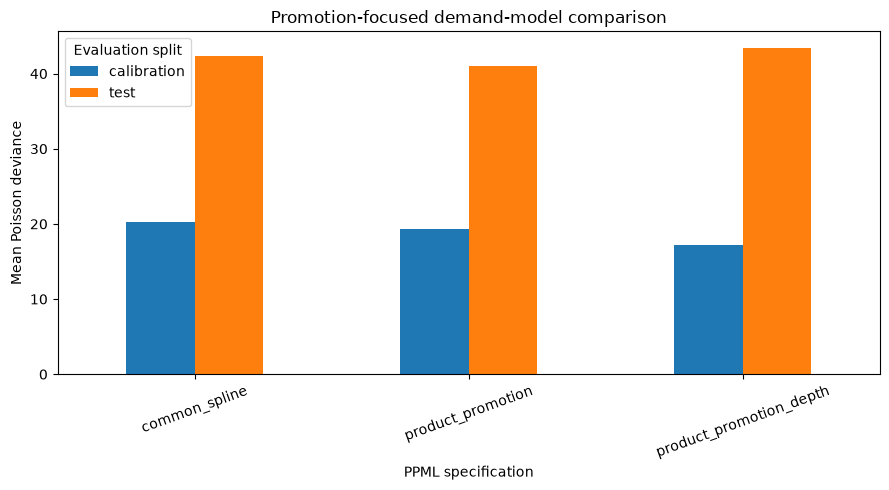

Saved: C:\Users\janza\price-of-extrapolation\results\figures\promotion_model_comparison.png


In [50]:
plot_data = overall_metrics.pivot(
    index="model",
    columns="split",
    values="mean_poisson_deviance",
).reindex(model_order)

fig, ax = plt.subplots(figsize=(9, 5))
plot_data.plot(kind="bar", ax=ax)

ax.set_xlabel("PPML specification")
ax.set_ylabel("Mean Poisson deviance")
ax.set_title(
    "Promotion-focused demand-model comparison"
)
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Evaluation split")

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "promotion_model_comparison.png"
)
fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print(f"Saved: {figure_path}")

## 17. Export exact rolling PPML artifacts for candidate pricing

The pricing notebook evaluates candidate prices with the same rolling
spline PPML used for forecasting. This cell saves each rolling
`product_promotion` model and the decision-time covariates needed for
exact counterfactual prediction.

In [51]:
MODEL_DIR = PROJECT_ROOT / "results" / "models"
ROLLING_MODEL_DIR = (
    MODEL_DIR / "product_promotion_rolling_ppml"
)
ROLLING_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ROLLING_MANIFEST_PATH = (
    MODEL_DIR
    / "product_promotion_rolling_ppml_manifest.pkl"
)
PREDICTION_CONTEXT_PATH = (
    PROCESSED_DIR
    / "product_promotion_prediction_context.pkl"
)

FROZEN_MODEL_NAME = "product_promotion"
artifact_rows = []

for block_number, block_start in enumerate(
    range(
        0,
        len(forecast_weeks),
        REFIT_EVERY_N_WEEKS,
    )
):
    block_weeks = forecast_weeks[
        block_start:
        block_start + REFIT_EVERY_N_WEEKS
    ]
    first_forecast_week = int(
        block_weeks[0]
    )

    fit_data = model_data[
        model_data["week"]
        < first_forecast_week
    ].copy()
    prediction_data = model_data[
        model_data["week"].isin(
            block_weeks
        )
    ].copy()

    if fit_data.empty or prediction_data.empty:
        continue

    (
        fit_data,
        prediction_data,
        lower,
        upper,
    ) = prepare_price_for_spline(
        fit_data,
        prediction_data,
    )

    formula = build_formula(
        FROZEN_MODEL_NAME,
        lower_bound=lower,
        upper_bound=upper,
    )

    result = smf.glm(
        formula=formula,
        data=fit_data,
        family=sm.families.Poisson(),
    ).fit(maxiter=100)

    model_filename = (
        f"{FROZEN_MODEL_NAME}_"
        f"block_{block_number:03d}.pickle"
    )
    model_path = (
        ROLLING_MODEL_DIR
        / model_filename
    )

    result.save(model_path)

    artifact_rows.append(
        {
            "model": FROZEN_MODEL_NAME,
            "block_number": block_number,
            "first_forecast_week": int(
                block_weeks.min()
            ),
            "last_forecast_week": int(
                block_weeks.max()
            ),
            "fit_last_week": int(
                fit_data["week"].max()
            ),
            "spline_lower": float(lower),
            "spline_upper": float(upper),
            "model_filename": model_filename,
            "converged": bool(
                result.converged
            ),
        }
    )

    print(
        "Saved exact PPML artifact:",
        model_filename,
        "| forecast weeks",
        int(block_weeks.min()),
        "to",
        int(block_weeks.max()),
    )

rolling_manifest = pd.DataFrame(
    artifact_rows
)

if rolling_manifest.empty:
    raise RuntimeError(
        "No rolling PPML artifacts were created."
    )

rolling_manifest.to_pickle(
    ROLLING_MANIFEST_PATH
)

context_columns = [
    "store_upc",
    "upc",
    "week",
    "calendar_month",
    "scaled_time_trend",
    "thanksgiving_week",
    "christmas_week",
    "new_year_week",
    "easter_week",
    "log1p_lag_move",
    "log1p_lag_move_mean_4",
    "price_imputed_indicator",
    "promotion_indicator",
    "post_promotion_indicator",
]

prediction_context = (
    model_data.loc[
        model_data["week"].isin(
            forecast_weeks
        ),
        context_columns,
    ]
    .copy()
    .drop_duplicates(
        ["store_upc", "week"]
    )
    .sort_values(
        ["week", "store_upc"]
    )
    .reset_index(drop=True)
)

if prediction_context.duplicated(
    ["store_upc", "week"]
).any():
    raise ValueError(
        "Prediction context contains duplicate panel-weeks."
    )

prediction_context.to_pickle(
    PREDICTION_CONTEXT_PATH
)

print(
    "Saved manifest:",
    ROLLING_MANIFEST_PATH,
)
print(
    "Saved prediction context:",
    PREDICTION_CONTEXT_PATH,
)
display(rolling_manifest)

Saved exact PPML artifact: product_promotion_block_000.pickle | forecast weeks 220 to 223
Saved exact PPML artifact: product_promotion_block_001.pickle | forecast weeks 224 to 227
Saved exact PPML artifact: product_promotion_block_002.pickle | forecast weeks 228 to 231
Saved exact PPML artifact: product_promotion_block_003.pickle | forecast weeks 232 to 235
Saved exact PPML artifact: product_promotion_block_004.pickle | forecast weeks 236 to 239
Saved exact PPML artifact: product_promotion_block_005.pickle | forecast weeks 240 to 243
Saved exact PPML artifact: product_promotion_block_006.pickle | forecast weeks 244 to 247
Saved exact PPML artifact: product_promotion_block_007.pickle | forecast weeks 248 to 251
Saved exact PPML artifact: product_promotion_block_008.pickle | forecast weeks 252 to 255
Saved exact PPML artifact: product_promotion_block_009.pickle | forecast weeks 256 to 259
Saved exact PPML artifact: product_promotion_block_010.pickle | forecast weeks 260 to 267
Saved exac

,model,block_number,first_forecast_week,last_forecast_week,fit_last_week,spline_lower,spline_upper,model_filename,converged
0,product_promotion,0,220,223,218,-0.01005,1.373716,product_promotion_block_000.pickle,True
1,product_promotion,1,224,227,223,-0.01005,1.378997,product_promotion_block_001.pickle,True
2,product_promotion,2,228,231,227,-0.01005,1.388791,product_promotion_block_002.pickle,True
3,product_promotion,3,232,235,231,-0.01005,1.403643,product_promotion_block_003.pickle,True
4,product_promotion,4,236,239,235,-0.01005,1.403643,product_promotion_block_004.pickle,True
5,product_promotion,5,240,243,239,-0.01005,1.418277,product_promotion_block_005.pickle,True
6,product_promotion,6,244,247,243,-0.01005,1.430052,product_promotion_block_006.pickle,True
7,product_promotion,7,248,251,247,-0.01005,1.456287,product_promotion_block_007.pickle,True
8,product_promotion,8,252,255,251,-0.01005,1.456287,product_promotion_block_008.pickle,True
9,product_promotion,9,256,259,255,-0.01005,1.456287,product_promotion_block_009.pickle,True


## 17. Save reproducibility and model-comparison outputs

In [52]:
prediction_path = (
    PROCESSED_DIR
    / "final_demand_model_predictions.pkl"
)
metrics_path = (
    TABLE_DIR
    / "final_demand_model_comparison.csv"
)
promotion_path = (
    TABLE_DIR
    / "final_demand_model_by_promotion_state.csv"
)
product_selection_path = (
    TABLE_DIR
    / "product_selection_table.csv"
)
product_flow_path = (
    TABLE_DIR
    / "product_selection_flow.csv"
)
store_selection_path = (
    TABLE_DIR
    / "store_selection_table.csv"
)
panel_selection_path = (
    TABLE_DIR
    / "panel_selection_table.csv"
)
selected_products_path = (
    TABLE_DIR
    / "selected_products.csv"
)

predictions.to_pickle(prediction_path)
overall_metrics.to_csv(metrics_path, index=False)
promotion_metrics.to_csv(
    promotion_path,
    index=False,
)
product_selection.to_csv(
    product_selection_path,
    index=False,
)
product_selection_flow.to_csv(
    product_flow_path,
    index=False,
)
store_selection.to_csv(
    store_selection_path,
    index=False,
)
panel_selection.to_csv(
    panel_selection_path,
    index=False,
)
pd.DataFrame(
    {"upc": selected_upcs}
).to_csv(
    selected_products_path,
    index=False,
)

print(f"Saved predictions: {prediction_path}")
print(f"Saved metrics: {metrics_path}")
print(f"Saved promotion diagnostics: {promotion_path}")
print(f"Saved product selection: {product_selection_path}")
print(f"Saved product flow: {product_flow_path}")
print(f"Saved store selection: {store_selection_path}")
print(f"Saved panel selection: {panel_selection_path}")
print(f"Saved selected UPCs: {selected_products_path}")

Saved predictions: C:\Users\janza\price-of-extrapolation\data\processed\final_demand_model_predictions.pkl
Saved metrics: C:\Users\janza\price-of-extrapolation\results\tables\final_demand_model_comparison.csv
Saved promotion diagnostics: C:\Users\janza\price-of-extrapolation\results\tables\final_demand_model_by_promotion_state.csv
Saved product selection: C:\Users\janza\price-of-extrapolation\results\tables\product_selection_table.csv
Saved product flow: C:\Users\janza\price-of-extrapolation\results\tables\product_selection_flow.csv
Saved store selection: C:\Users\janza\price-of-extrapolation\results\tables\store_selection_table.csv
Saved panel selection: C:\Users\janza\price-of-extrapolation\results\tables\panel_selection_table.csv
Saved selected UPCs: C:\Users\janza\price-of-extrapolation\results\tables\selected_products.csv


## Decision rule

Freeze the model that minimizes **calibration-period mean Poisson deviance**, provided that:

1. it does not create extreme prediction failures;
2. its promotion-week performance improves materially or at least does not deteriorate;
3. its fitted price response remains economically plausible;
4. test-period results are inspected only after the calibration-based choice is fixed.

The selected model's rolling calibration losses are then passed to the local-support and reliability-calibration stage.